# HTS Classifier

In [45]:
# Imports
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report

## Load Dataset
<br>

<footer> The original Hugging Face dataset is no longer publicly available.
The project was developed using a locally cached copy downloaded on June 2, 2026. </footer>

In [46]:
from src.data_loader import *

df = load_cross_dataset()
hts = load_hts_schedule(
    "data/hts_2026_revision_10_csv.csv"
)

In [47]:
df.head()

,messages
0,"[{'role': 'user', 'content': 'What is the HTS ..."
1,"[{'role': 'user', 'content': 'What is the HTS ..."
2,"[{'role': 'user', 'content': 'What is the HTS ..."
3,"[{'role': 'user', 'content': 'What is the HTS ..."
4,"[{'role': 'user', 'content': 'What is the HTS ..."


In [48]:
df.shape

(18254, 1)

In [49]:
df.columns

Index(['messages'], dtype='object')

In [50]:
# Look at one full example
df.iloc[0]["messages"]

array([{'role': 'user', 'content': 'What is the HTS US Code for a horizontal injection molding machine and molds for producing rubber parts?'},
       {'role': 'assistant', 'content': "HTS US Code -> 8477.10.9015; 8480.71.8045\nReasoning -> The horizontal injection molding machine is classified under HTS code 8477.10.9015, which pertains to machinery for working rubber or plastics or for the manufacture of products from these materials, specifically injection-molding machines used for processing rubber or other thermosetting materials. The machine's features, including a clamping force of 220 tons, powered mold height adjustment, a central ejector, a computerized control system, and a double brush discharging system, align with the definition of machinery classified under this HTS code. \n\nThe molds, specifically designed for injection molding of rubber parts such as O-rings and U-cups, are classified under HTS code 8480.71.8045, which covers molds for rubber or plastics, specifically

## Data Cleaning

In [51]:
from src.preprocessing import *

parsed_df = df["messages"].apply(parse_messages)

In [52]:
parsed_df['question'][0]

'What is the HTS US Code for a horizontal injection molding machine and molds for producing rubber parts?'

In [53]:
parsed_df['response'][1]

'HTS US Code -> 6111.20.1000; 6106.10.0030\nReasoning -> The product in question is a shirt constructed of knit fabric made entirely of cotton, specifically designed for infants and toddlers. The HTSUS classification is determined based on the type of garment, the material used, and the target demographic. \n\n1. The shirt is categorized under "babies garments and clothing accessories, knitted or crocheted: of cotton: blouses and shirts, except those imported as parts of sets," which aligns with HTS Code 6111.20.1000 for infant sizes (3-6 months through 18-24 months).\n   \n2. For toddler sizes (2T-3T), the shirt falls under "womens or girls blouses and shirts, knitted or crocheted: of cotton: girls other," which corresponds to HTS Code 6106.10.0030.\n\n3. Both classifications are applicable as the shirt is imported in different sizes catering to both infants and toddlers, confirming the correct HTS codes for the respective size categories.\n\n4. The duty rate for both classifications 

In [54]:
parsed_df = parsed_df.apply(
    extract_fields,
    axis=1
)

parsed_df["clean_text"] = (
    parsed_df["product_description"]
    .apply(clean_text)
)

In [55]:
parsed_df.isnull().sum()

,0
product_description,0
hts_codes,0
reasoning,0
clean_text,0


In [56]:
parsed_df.duplicated().sum()

np.int64(0)

In [57]:
parsed_df.shape

(18254, 4)

In [58]:
parsed_df.sample(5, random_state=42)

,product_description,hts_codes,reasoning,clean_text
10731,What is the HTS US Code for a Jump N Start por...,8504.40.9530,The Jump N Start portable rechargeable power s...,a jump n start portable rechargeable power sta...
2608,What is the HTS US Code for automatic stacking...,8426.19.0000,The product in question includes three types o...,automatic stacking cranes rubber tire gantry c...
14585,"What is the HTS US Code for 1,3-Dinitrobenzene?",2904.20.3500,"The product in question is 1,3-Dinitrobenzene ...",1 3-dinitrobenzene
4254,What is the HTS US Code for a ladies handbag m...,4202.22.7000,"The product in question is a ladies handbag, s...",a ladies handbag made of silk with glass bead ...
6925,What is the HTS US Code for incomplete mini-sp...,"8415.90.8065, 8415.90.8085, 9903.88.15",The classification of the incomplete mini-spli...,incomplete mini-split air conditioning systems...


### Define Target Data - 4-digit code

In [59]:
# Extract primary hts code
parsed_df["primary_hts"] = (
    parsed_df["hts_codes"]
    .str.split(";")
    .str[0]
    .str.strip()
)

# Convert the primary hts code into 4-digit label
parsed_df["hts_4digit"] = (
    parsed_df["primary_hts"]
    .str.replace(".", "", regex=False)
    .str[:4]
)

In [60]:
# Drop N/A rows
parsed_df = parsed_df.dropna(
    subset=["clean_text", "hts_4digit"]
).copy()

label_encoder = LabelEncoder()

# Fit the encoder on the 4-digit
parsed_df["label"] = label_encoder.fit_transform(
    parsed_df["hts_4digit"]
)

In [61]:
parsed_df.head()

,product_description,hts_codes,reasoning,clean_text,primary_hts,hts_4digit,label
0,What is the HTS US Code for a horizontal injec...,8477.10.9015; 8480.71.8045,The horizontal injection molding machine is cl...,a horizontal injection molding machine and mol...,8477.10.9015,8477,418
1,What is the HTS US Code for an infant and todd...,6111.20.1000; 6106.10.0030,The product in question is a shirt constructed...,an infant and toddler shirt made of 100% cotto...,6111.20.1000,6111,212
2,What is the HTS US Code for L-Lysine HCL (CAS#...,2922.41.0010,The HTS US Code 2922.41.0010 is applicable to ...,l-lysine hcl (cas# 657-27-2) from china,2922.41.0010,2922,61
3,What is the HTS US Code for polyvinylchloride ...,3904.10.0000,The product in question is polyvinylchloride (...,polyvinylchloride (pvc) powder used in the aut...,3904.10.0000,3904,123
4,What is the HTS US Code for polyvinylchloride ...,3912.31.0090,The product in question is classified under HT...,polyvinylchloride (pvc) powder used in the man...,3912.31.0090,3912,131


In [62]:
# Check number of unique classes and shape
print(parsed_df["hts_4digit"].nunique())
print(parsed_df.shape)

549
(18254, 7)


In [63]:
counts = parsed_df["hts_4digit"].value_counts()
counts.describe()

,count
count,549.000000
mean,33.249545
std,79.447738
min,1.000000
25%,2.000000
50%,8.000000
75%,31.000000
max,1123.000000


In [64]:
print(counts.head())

hts_4digit
6110    1123
8481     715
3921     502
6102     432
3920     337
Name: count, dtype: int64


#### There's a significant difference between the mean (33.25) and medium (8.0), which indicates that there's a positve skew.

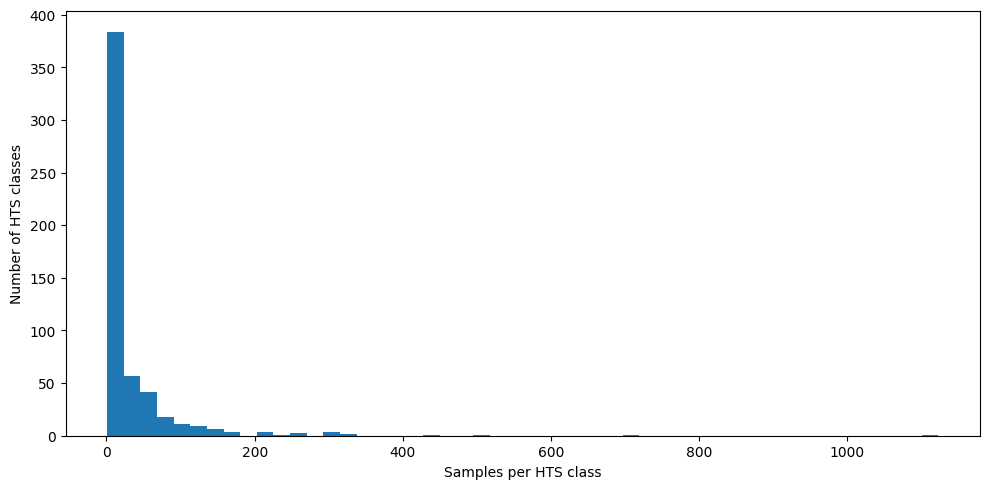

In [65]:
# Visualize distribution

plt.figure(figsize=(10,5))
counts.plot(kind="hist", bins=50)
plt.xlabel("Samples per HTS class")
plt.ylabel("Number of HTS classes")
plt.tight_layout()
plt.show()

In [66]:
# Keep only classes with at least 10 samples
valid_classes = counts[counts >= 10].index

# Filter dataset by removing rare classes
filtered_df = parsed_df[parsed_df["hts_4digit"].isin(valid_classes)].copy()

print(filtered_df["hts_4digit"].nunique())
print("Updated Shape:", filtered_df.shape)

258
Updated Shape: (17378, 7)


#### Now after filtering we have 258 classes that have at least 10 samples

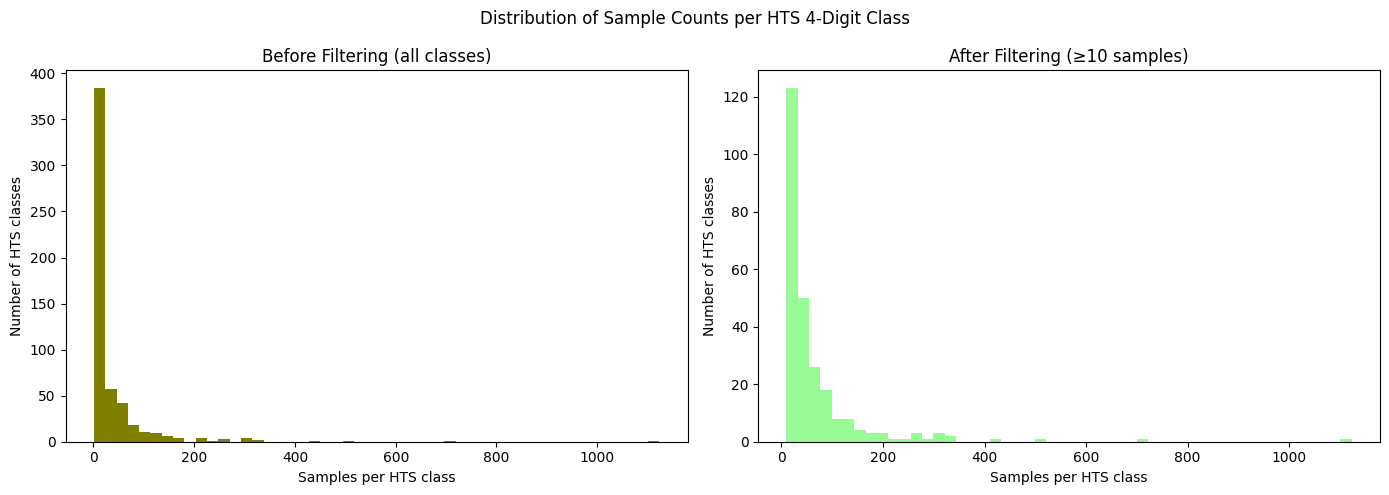

In [67]:
# Updated Visualization with filtered data

parsed_counts = parsed_df["hts_4digit"].value_counts()
filtered_counts = filtered_df["hts_4digit"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# parsed_df, no filter.
axes[0].hist(parsed_counts, bins=50, color="olive")
axes[0].set_xlabel("Samples per HTS class")
axes[0].set_ylabel("Number of HTS classes")
axes[0].set_title("Before Filtering (all classes)")

# filtered_df, filtered with at least >10 samples.
axes[1].hist(filtered_counts, bins=50, color="palegreen")
axes[1].set_xlabel("Samples per HTS class")
axes[1].set_ylabel("Number of HTS classes")
axes[1].set_title("After Filtering (≥10 samples)")

plt.suptitle("Distribution of Sample Counts per HTS 4-Digit Class")
plt.tight_layout()
plt.show()


In [68]:
# Top HTS Classes by number of samples.

top10 = filtered_counts.head(10).reset_index()
top10.columns = ["hts_4digit", "sample_count"]
top10

,hts_4digit,sample_count
0,6110,1123
1,8481,715
2,3921,502
3,6102,432
4,3920,337
5,3926,335
6,8205,313
7,3923,304
8,6111,304
9,7318,296


## Test/Train Split

In [69]:
X = filtered_df["clean_text"]
y = filtered_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

### TD-IDF Vectorization

In [70]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Model 1: Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression Model
logreg_model = LogisticRegression(max_iter=1000,n_jobs=-1)

logreg_model.fit(X_train_tfidf, y_train)

# Make predictions
log_pred = logreg_model.predict(X_test_tfidf)

In [72]:
# Note: create evaluate model function for all models

# Quick eval
print(recall_score(y_test, log_pred, average='weighted', zero_division=0))
print(precision_score(y_test, log_pred, average='weighted', zero_division=0))

0.5408515535097813
0.564435348909751


## Model 2: SVM

In [73]:
from sklearn.svm import LinearSVC

# Train SVM Model
svm_model = LinearSVC(class_weight="balanced", dual=False)

svm_model.fit(X_train_tfidf, y_train)

# Make prediction
svm_pred = svm_model.predict(X_test_tfidf)

In [74]:
# Quick eval
print(recall_score(y_test, svm_pred, average='weighted', zero_division=0))
print(precision_score(y_test, svm_pred, average='weighted', zero_division=0))

0.6812428078250863
0.6936582220325425


## Model 3: Naive Bayes

> Add blockquote



In [75]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

In [76]:
# Quick eval
print(recall_score(y_test, nb_pred, average='weighted', zero_division=0))
print(precision_score(y_test, nb_pred, average='weighted', zero_division=0))

0.2891254315304948
0.3746429003453253


## Model 4: Feedforward Neural Network (FFNN)

In [77]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# Convert TF-IDF (sparse) to tensor.
X_train_dense = torch.FloatTensor(X_train_tfidf.toarray())
X_test_dense = torch.FloatTensor(X_test_tfidf.toarray())
y_train_t = torch.LongTensor(y_train.values)
y_test_t = torch.LongTensor(y_test.values)

print(X_train_dense.shape, X_test_dense.shape)

torch.Size([13902, 27534]) torch.Size([3476, 27534])


In [78]:
n_features = X_train_dense.shape[1]
n_classes = len(label_encoder.classes_)

class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

ffnn_model = FFNN(n_features, hidden_dim=256, num_classes=n_classes).to(device)
optimizer = torch.optim.Adam(ffnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_dataset = TensorDataset(X_train_dense, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# Training
for epoch in range(100):
    ffnn_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = ffnn_model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Avg Loss: {total_loss/len(train_loader):.4f}")


Using: cuda
Epoch 10, Loss: 0.4190, Avg Loss: 0.1887
Epoch 20, Loss: 0.0055, Avg Loss: 0.0715
Epoch 30, Loss: 0.2051, Avg Loss: 0.0603
Epoch 40, Loss: 0.1167, Avg Loss: 0.0525
Epoch 50, Loss: 0.3282, Avg Loss: 0.0480
Epoch 60, Loss: 0.0001, Avg Loss: 0.0466
Epoch 70, Loss: 0.0004, Avg Loss: 0.0444
Epoch 80, Loss: 0.0468, Avg Loss: 0.0411
Epoch 90, Loss: 0.0001, Avg Loss: 0.0414
Epoch 100, Loss: 0.0726, Avg Loss: 0.0415


In [79]:
ffnn_model.eval()
with torch.no_grad():
    X_test_gpu = X_test_dense.to(device)
    ffnn_logits = ffnn_model(X_test_gpu)
    ffnn_pred = ffnn_logits.argmax(dim=1).cpu().numpy()

In [80]:
# Quick eval
print(recall_score(y_test, ffnn_pred, average='weighted', zero_division=0))
print(precision_score(y_test, ffnn_pred, average='weighted', zero_division=0))

0.6421173762945915
0.6745481191763535


## Model Evaluation & Comparison

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    """
    Calculate standard metrics for classification models. Returns a dictionary with the metrics
    to compare each other.
    """
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1 (weighted)": f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    return metrics

In [82]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, log_pred))
results.append(evaluate_model("SVM", y_test, svm_pred))
results.append(evaluate_model("Naive Bayes", y_test, nb_pred))
results.append(evaluate_model("FFNN", y_test, ffnn_pred))

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression,0.540852,0.564435,0.540852,0.501474
1,SVM,0.681243,0.693658,0.681243,0.676016
2,Naive Bayes,0.289125,0.374643,0.289125,0.232192
3,FFNN,0.642117,0.674548,0.642117,0.637702


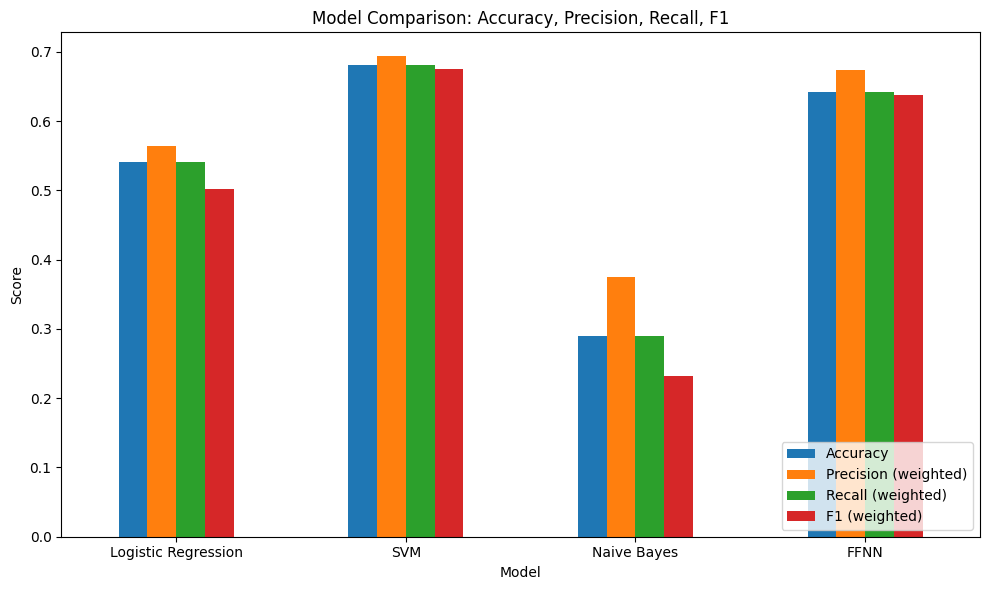

In [83]:
comparison_df.set_index("Model")[["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Comparison: Accuracy, Precision, Recall, F1")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

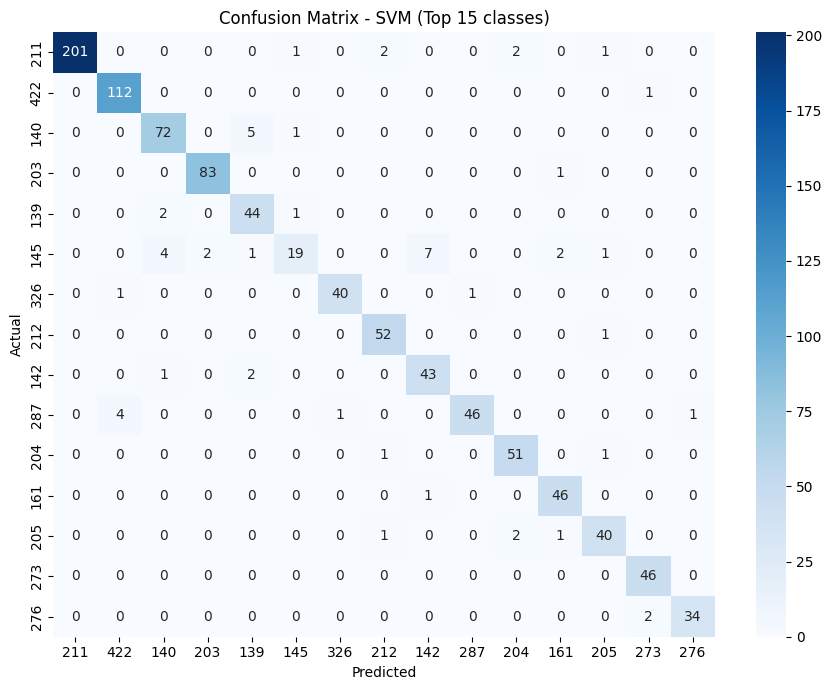

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Update for best result model
best_pred = svm_pred  # o svm_pred, el que haya ganado
best_name = "SVM"

y_test_reset = pd.Series(y_test).reset_index(drop=True)

top_classes = y_test_reset.value_counts().nlargest(15).index
mask = y_test_reset.isin(top_classes)

cm = confusion_matrix(
    y_test_reset[mask],
    pd.Series(best_pred)[mask],
    labels=top_classes
)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=top_classes, yticklabels=top_classes)
plt.title(f"Confusion Matrix - {best_name} (Top 15 classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()